# Lesson 06: Probability & Distributions

> Interactive practice scaffold strictly following the **## Build It** section in **docs/en.md**, followed by author extensions in **Extra Concepts**.


### Setup & Imports


In [32]:
import math
import random

random.seed(42)

def check_test(name, actual, expected, tol=1e-3):
    """
    Test verification helper.
    Prints ✅ when actual matches expected within tolerance, or ❗ on failure / None.
    """
    if actual is None:
        print(f"❗ {name} = None (Expected: {expected})")
        return False
    passed = False
    try:
        if isinstance(expected, (int, float)) and isinstance(actual, (int, float)):
            passed = math.isclose(actual, expected, abs_tol=tol, rel_tol=tol)
        elif isinstance(expected, (list, tuple)) and isinstance(actual, (list, tuple)):
            if len(actual) == len(expected):
                passed = all(
                    math.isclose(a, b, abs_tol=tol, rel_tol=tol) if isinstance(b, (int, float)) and isinstance(a, (int, float))
                    else (all(math.isclose(x, y, abs_tol=tol, rel_tol=tol) for x, y in zip(a, b)) if isinstance(b, (list, tuple)) and isinstance(a, (list, tuple)) else a == b)
                    for a, b in zip(actual, expected)
                )
        else:
            passed = (actual == expected)
    except Exception:
        passed = False

    if passed:
        print(f"✅ {name} = {actual}")
    else:
        print(f"❗ {name} = {actual} (Expected: {expected})")
    return passed

print("Setup complete. Random seed set to 42. Visual test verification (✅ / ❗) ready.")


Setup complete. Random seed set to 42. Visual test verification (✅ / ❗) ready.


### Step 1: Probability basics
- `factorial(n)`: Compute factorial $n! = \prod_{i=1}^n i = 1 \times 2 \times \dots \times n$ (with $0! = 1$)
- `combinations(n, k)`: Number of combinations $\binom{n}{k} = \frac{n!}{k!(n-k)!}$
- `conditional_probability(p_a_and_b, p_b)`: Conditional probability $P(A|B) = \frac{P(A \cap B)}{P(B)}$


In [ ]:
def factorial(n):
    # Calculate the factorial of n (n! = 1 * 2 * ... * n, with 0! = 1).
    # Example: n = 5 -> returns 120
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result


def combinations(n, k):
    # Calculate combinations nCr: number of ways to choose k items from n.
    # Example: n = 5, k = 2 -> returns 10
    # Formula: n! / (k! * (n - k)!)
    return factorial(n) // (factorial(k) * factorial(n - k))


def conditional_probability(p_a_and_b, p_b):
    # Calculate conditional probability P(A|B) = P(A ∩ B) / P(B).
    # Example: p_a_and_b = 4/52, p_b = 12/52 -> returns 1/3 (0.3333)
    return p_a_and_b / p_b


# --- Step 1 Tests (from docs) ---
try:
    p_king_given_face = conditional_probability(4 / 52, 12 / 52)
    check_test("P(King | Face card)", round(p_king_given_face, 4) if p_king_given_face is not None else None, 0.3333)
    check_test("factorial(5)", factorial(5), 120)
    check_test("combinations(5, 2)", combinations(5, 2), 10)
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Step 1 tests: {e}")


❗ Please run the Setup cell at the top first!


### Step 2: PMF and PDF from scratch
- `bernoulli_pmf(k, p)`: PMF for single trial: $P(X = k) = p^k (1 - p)^{1 - k}$ where $k \in \{0, 1\}$
- `categorical_pmf(k, probs)`: PMF for categorical choice: $P(X = k) = p_k$ where $\sum_{i} p_i = 1$
- `poisson_pmf(k, lam)`: PMF for count of rare events: $P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$
- `uniform_pdf(x, a, b)`: Continuous Uniform density: $f(x) = \frac{1}{b - a}$ for $x \in [a, b]$, else $0$
- `normal_pdf(x, mu, sigma)`: Gaussian density: $f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$


In [34]:
def bernoulli_pmf(k, p):
    # TODO: Compute PMF for Bernoulli(p).
    # Example: k = 1, p = 0.7 -> returns 0.7; k = 0, p = 0.7 -> returns 0.3
    return p if k == 1 else 1 - p


def categorical_pmf(k, probs):
    # TODO: Compute PMF for Categorical distribution.
    # Example: k = 0, probs = [0.7, 0.2, 0.1] -> returns 0.7
    return probs[k]


def poisson_pmf(k, lam):
    # TODO: Compute PMF for Poisson distribution with rate lambda.
    # Example: k = 3, lam = 2.5 -> returns ~0.2138
    # Formula: P(X = k) = (lambda^k * e^(-lambda)) / k!
    return (lam ** k) * math.exp(-lam) / factorial(k)


def uniform_pdf(x, a, b):
    # TODO: Compute PDF for continuous Uniform distribution over interval [a, b].
    # Example: x = 2.5, a = 1.0, b = 4.0 -> returns 1.0 / (4.0 - 1.0) = 0.3333
    # Formula: f(x) = 1 / (b - a) when a <= x <= b, otherwise 0.
    if a <= x <= b:
        return 1.0 / (b - a)
    return 0.0


def normal_pdf(x, mu, sigma):
    # TODO: Compute PDF for Normal(mu, sigma).
    # Example: x = 0.0, mu = 0.0, sigma = 1.0 -> returns ~0.3989
    # Formula: f(x) = (1 / (sigma * sqrt(2 * pi))) * exp(-0.5 * ((x - mu) / sigma)^2)
    # Hint: Break computation into the normalization coefficient and the exponential power.
    import math
    coeff = 1.0 / (sigma * math.sqrt(2 * math.pi))
    exponent = -0.5 * ((x - mu) / sigma) ** 2
    return coeff * math.exp(exponent)


# --- Step 2 Tests (from docs) ---
try:
    b_val = bernoulli_pmf(1, 0.7)
    check_test("Bernoulli(k=1, p=0.7)", b_val, 0.7)

    c_val = categorical_pmf(0, [0.7, 0.2, 0.1])
    check_test("Categorical(k=0)", c_val, 0.7)

    p_val = poisson_pmf(3, 2.5)
    check_test("Poisson(k=3, lam=2.5)", round(p_val, 4) if p_val is not None else None, 0.2138)

    u_val = uniform_pdf(2.5, 1, 4)
    check_test("Uniform(x=2.5, a=1, b=4)", round(u_val, 4) if u_val is not None else None, 0.3333)

    n_val = normal_pdf(0, 0, 1)
    check_test("Normal(x=0, mu=0, sigma=1)", round(n_val, 4) if n_val is not None else None, 0.3989)
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Step 2 tests: {e}")


✅ Bernoulli(k=1, p=0.7) = 0.7
✅ Categorical(k=0) = 0.7
✅ Poisson(k=3, lam=2.5) = 0.2138
✅ Uniform(x=2.5, a=1, b=4) = 0.3333
✅ Normal(x=0, mu=0, sigma=1) = 0.3989


### Step 3: Expected value and variance
- `expected_value(values, probabilities)`: Expected value $\mathbb{E}[X] = \sum_{i} x_i P(X = x_i)$
- `variance(values, probabilities)`: Variance $\text{Var}(X) = \sum_{i} P(X = x_i)(x_i - \mu)^2 = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$
- Standard deviation: $\sigma = \sqrt{\text{Var}(X)}$


In [35]:
def expected_value(values, probabilities):
    # TODO: Calculate expected value E[X] (probability-weighted average of outcomes).
    # Example: values = [1, 2, 3, 4, 5, 6], probabilities = [1/6] * 6 -> returns 3.5
    # Formula: E[X] = sum over i of (x_i * p_i)
    # Hint: Iterate through paired values and probabilities, multiply them, and sum.
    return sum( (value * prob) for value, prob in zip(values, probabilities))


def variance(values, probabilities):
    # TODO: Calculate variance Var(X) (expected squared deviation from the mean).
    # Example: values = [1, 2, 3, 4, 5, 6], probabilities = [1/6] * 6 -> returns ~2.9167
    # Formula: Var(X) = sum over i of (p_i * (x_i - mu)^2), where mu = E[X].
    # Hint: Compute mean mu first using expected_value, then sum weighted squared differences.
    mu = expected_value(values, probabilities)
    return sum( prob * ((value - mu) ** 2) for value, prob in zip(values, probabilities) )


# --- Step 3 Tests (from docs) ---
try:
    die_values = [1, 2, 3, 4, 5, 6]
    die_probs = [1 / 6] * 6
    mu = expected_value(die_values, die_probs)
    var = variance(die_values, die_probs)
    sd = (var ** 0.5) if var is not None else None

    check_test("Die: E[X]", round(mu, 4) if mu is not None else None, 3.5000)
    check_test("Die: Var(X)", round(var, 4) if var is not None else None, 2.9167)
    check_test("Die: SD", round(sd, 4) if sd is not None else None, 1.7078)
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Step 3 tests: {e}")


✅ Die: E[X] = 3.5
✅ Die: Var(X) = 2.9167
✅ Die: SD = 1.7078


### Step 4: Sampling from distributions
- `sample_bernoulli(p, n=1)`: Binary sampling using uniform float $r \sim \text{Uniform}(0, 1)$:
  $$\text{outcome} = \begin{cases} 1 & \text{if } r < p \\ 0 & \text{if } r \ge p \end{cases}$$
- `sample_categorical(probs, n=1)`: Inverse transform sampling using cumulative sum $C_i = \sum_{j=0}^i p_j$:
  $$\text{category} = \min \{ i \mid C_i \ge r \}, \quad r \sim \text{Uniform}(0, 1)$$
- `sample_normal_box_muller(mu, sigma, n=1)`: Box-Muller transform from $u_1, u_2 \sim \text{Uniform}(0, 1)$:
  $$z = \sqrt{-2 \ln(u_1)} \cos(2\pi u_2), \quad x = \mu + \sigma z \sim \mathcal{N}(\mu, \sigma^2)$$


In [36]:
def sample_bernoulli(p, n=1):
    # TODO: Draw n independent random samples from Bernoulli(p).
    # Example: p = 0.7, n = 5 -> returns e.g. [1, 1, 0, 1, 0]
    # Hint: Generate random float r in [0, 1). If r < p, outcome is 1, else 0.

    return [1 if random.random() < p else 0 for _ in range(n)]


def sample_categorical(probs, n=1):
    # TODO: Draw n independent samples from Categorical distribution using inverse transform sampling.
    # Example: probs = [0.7, 0.2, 0.1], n = 5 -> returns e.g. [0, 0, 1, 0, 2]
    # Hint:
    # 1. Build a cumulative probability array (running sum of probs).
    # 2. For each sample, generate random float r in [0, 1).
    # 3. Find the first category index where cumulative prob is >= r.
    cum = []
    result = []
    total = 0
    for i in range(len(probs)): 
        total += probs[i]
        cum.append(total)
    for i in range(n): 
        sample = random.random()
        for idx, item in enumerate(cum): 
            if (sample <= item): 
                result.append(idx)
                break
        
    return result

def sample_normal_box_muller(mu, sigma, n=1):
    # TODO: Draw n samples from Normal(mu, sigma) using the Box-Muller transform.
    # Example: mu = 0.0, sigma = 1.0, n = 3 -> returns e.g. [0.42, -1.15, 0.08]
    # Hint: For each sample:
    # 1. Generate two uniform random numbers u1, u2 in (0, 1).
    # 2. Compute standard normal z-score: z = sqrt(-2 * ln(u1)) * cos(2 * pi * u2).
    # 3. Scale and shift: x = mu + sigma * z.
    result = []
    for i in range(n): 
        u1, u2 = random.random(), random.random()
        z = math.sqrt( -2 * math.log(u1)) * math.cos(2 * math.pi * u2)
        x = mu + sigma * z
        result.append(x)
    return result 



# --- Step 4 Tests (from docs) ---
try:
    b_samples = sample_bernoulli(0.7, 10)
    if b_samples is not None and isinstance(b_samples, list) and len(b_samples) == 10 and all(x in (0, 1) for x in b_samples):
        print(f"✅ sample_bernoulli (10 samples): {b_samples}")
    else:
        print(f"❗ sample_bernoulli: {b_samples} (Expected: list of 10 binary samples [0 or 1])")

    c_samples = sample_categorical([0.7, 0.2, 0.1], 10)
    if c_samples is not None and isinstance(c_samples, list) and len(c_samples) == 10 and all(x in (0, 1, 2) for x in c_samples):
        print(f"✅ sample_categorical (10 samples): {c_samples}")
    else:
        print(f"❗ sample_categorical: {c_samples} (Expected: list of 10 indices in {0, 1, 2})")

    n_samples = sample_normal_box_muller(0, 1, 5)
    if n_samples is not None and isinstance(n_samples, list) and len(n_samples) == 5 and all(isinstance(x, (int, float)) for x in n_samples):
        rounded_n = [round(x, 2) for x in n_samples]
        print(f"✅ sample_normal (5 samples): {rounded_n}")
    else:
        print(f"❗ sample_normal: {n_samples} (Expected: list of 5 float samples)")
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Step 4 tests: {e}")


✅ sample_bernoulli (10 samples): [1, 1, 1, 1, 0, 1, 0, 1, 1, 1]
✅ sample_categorical (10 samples): [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
✅ sample_normal (5 samples): [-0.21, 0.82, -0.15, 1.79, -0.46]


### Step 5: Softmax and log probabilities
- `softmax(logits)`: Probability vector with numerical stability shift $c = \max(z)$:
  $$\text{softmax}(z)_i = \frac{e^{z_i - c}}{\sum_j e^{z_j - c}}$$
- `log_softmax(logits)`: Numerically stable log probabilities via LogSumExp:
  $$\log(\text{softmax}(z)_i) = z_i - \text{LogSumExp}(z), \quad \text{where } \text{LogSumExp}(z) = c + \ln\left(\sum_j e^{z_j - c}\right)$$
- `cross_entropy_loss(logits, target_index)`: Negative log-likelihood of ground-truth class $y$:
  $$\mathcal{L}_{CE} = -\log(\text{softmax}(z)_y) = -\text{log\_softmax}(z)_y$$


In [46]:
def softmax(logits):
    # TODO: Convert unnormalized logits into valid probabilities (summing to 1).
    # Example: logits = [2.0, 1.0, 0.1] -> returns ~[0.6590, 0.2424, 0.0986]
    # Formula: softmax(z_i) = exp(z_i) / sum(exp(z_j))
    # Hint: Subtract max(logits) from all elements before exp to prevent numerical overflow.
    logits = [logit - max(logits) for logit in logits]
    
    exps = [math.exp(logit) for logit in logits]

    sums = sum(exps)

    return [exp / sums for exp in exps]
    


def log_softmax(logits):
    # TODO: Compute log(softmax(z)) using numerically stable LogSumExp identity.
    # Example: logits = [2.0, 1.0, 0.1] -> returns ~[-0.4170, -1.4170, -2.3170]
    # Identity: log(softmax(z_i)) = z_i - LogSumExp(z)
    # where LogSumExp(z) = max(z) + ln(sum(exp(z_j - max(z))))
    c = max(logits)
    shifted = [logit - c for logit in logits]
    exps = [math.exp(logit) for logit in shifted]
    lse = c + math.log(sum(exps))

    return [(logit - lse) for logit in logits]




def cross_entropy_loss(logits, target_index):
    # TODO: Compute Cross-Entropy Loss for multi-class classification.
    # Example: logits = [2.0, 1.0, 0.1], target_index = 0 -> returns ~0.4170
    # Definition: Negative log-probability assigned to target class: -log(P(target)).
    # Hint: Use log_softmax to obtain log-probabilities, then negate the value at target_index.
    log_probs  = log_softmax(logits)
    return -log_probs[target_index]


# --- Step 5 Tests (from docs) ---
try:
    test_logits = [2.0, 1.0, 0.1]
    probs = softmax(test_logits)
    probs_rounded = [round(p, 4) for p in probs] if probs is not None else None
    check_test("softmax", probs_rounded, [0.6590, 0.2424, 0.0986])

    log_probs = log_softmax(test_logits)
    log_probs_rounded = [round(lp, 4) for lp in log_probs] if log_probs is not None else None
    check_test("log_softmax", log_probs_rounded, [-0.4170, -1.4170, -2.3170])

    loss = cross_entropy_loss(test_logits, 0)
    check_test("cross_entropy_loss (target=0)", round(loss, 4) if loss is not None else None, 0.4170)
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Step 5 tests: {e}")


✅ softmax = [0.659, 0.2424, 0.0986]
✅ log_softmax = [-0.417, -1.417, -2.317]
✅ cross_entropy_loss (target=0) = 0.417


### Step 6: Central Limit Theorem demonstration
- `demonstrate_clt(dist_fn, n_samples, n_averages)`: The sample average converges to a Gaussian distribution:
  $$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty$$


In [55]:
import numpy as np
def demonstrate_clt(dist_fn, n_samples, n_averages):
    # TODO: Simulate Central Limit Theorem.
    # Example: dist_fn = random.random, n_samples = 30, n_averages = 1000 -> returns list of 1000 sample means (mean ~ 0.5)
    # Hint: Run n_averages trials. In each trial, draw n_samples from dist_fn(),
    # compute their arithmetic mean, and record it. Return all computed sample averages.
    result = []
    
    for n_avg in range(n_averages): 
        sample_mean = np.mean([dist_fn() for n in range(n_samples)])
        result.append(sample_mean)

    return result
        
    


# --- Step 6 Tests (from docs) ---
try:
    clt_results = demonstrate_clt(random.random, 30, 1000)
    if clt_results is not None and isinstance(clt_results, list) and len(clt_results) == 1000:
        avg_mean = sum(clt_results) / len(clt_results)
        if math.isclose(avg_mean, 0.5, abs_tol=0.03):
            print(f"✅ CLT mean (n=30, 1000 averages): {avg_mean:.4f} (Expected: ~0.5000)")
        else:
            print(f"❗ CLT mean: {avg_mean:.4f} (Expected: ~0.5000, outside tolerance)")
    else:
        print(f"❗ demonstrate_clt: {clt_results} (Expected: list of 1000 sample means)")
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Step 6 tests: {e}")


✅ CLT mean (n=30, 1000 averages): 0.5003 (Expected: ~0.5000)


### Step 7: Visualization
- Plot continuous Normal PDF curve $f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$ across range $x \in [\mu - 5\sigma, \mu + 5\sigma]$ using `matplotlib`.


✅ normal_pdf curve ready to plot.


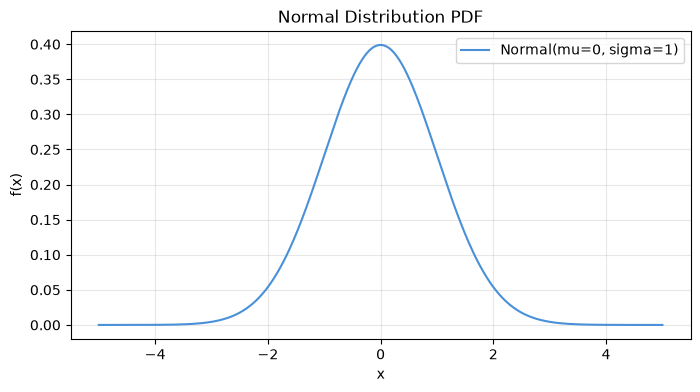

In [56]:
import matplotlib.pyplot as plt

# Generate Normal PDF curve
mu, sigma = 0, 1
xs = [mu + sigma * (i - 500) / 100 for i in range(1001)]
try:
    ys = [normal_pdf(x, mu, sigma) for x in xs]
    if ys and ys[0] is not None:
        print("✅ normal_pdf curve ready to plot.")
        plt.figure(figsize=(8, 4))
        plt.plot(xs, ys, label=f"Normal(mu={mu}, sigma={sigma})", color="#4a90d9")
        plt.title("Normal Distribution PDF")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    else:
        print("❗ Implement normal_pdf in Step 2 to plot the curve.")
except NameError:
    print("❗ Implement normal_pdf in Step 2 to plot.")
except Exception as e:
    print(f"❗ Implement normal_pdf in Step 2 to plot: {e}")


### Extra 1: Bayes' Theorem
- `bayes_theorem(p_b_given_a, p_a, p_b)`: Invert conditional probabilities via Bayes' rule:
  $$P(A|B) = \frac{P(B|A) P(A)}{P(B)}$$


In [ ]:
def bayes_theorem(p_b_given_a, p_a, p_b):
    # TODO: Compute posterior probability P(A|B) using Bayes' Theorem.
    # Example: p_b_given_a = 0.95 (sensitivity), p_a = 0.01 (prior), p_b = 0.05 (test positive) -> returns 0.19 (19%)
    # Formula: P(A|B) = (P(B|A) * P(A)) / P(B)
    pass


# --- Extra 1 Test: Medical Diagnostic Test ---
try:
    p_d_given_pos = bayes_theorem(0.95, 0.01, 0.05)
    check_test("P(Disease | Positive)", round(p_d_given_pos, 4) if p_d_given_pos is not None else None, 0.1900)
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Extra 1 test: {e}")


### Extra 2: Continuous Uniform Sampling
- `sample_uniform(a, b, n=1)`: Draw $n$ random float samples uniformly distributed in $[a, b]$:
  $$x = a + (b - a) \cdot r, \quad r \sim \text{Uniform}(0, 1)$$


In [ ]:
def sample_uniform(a, b, n=1):
    # TODO: Draw n random float samples uniformly distributed in continuous interval [a, b].
    # Example: a = 1.0, b = 4.0, n = 3 -> returns e.g. [2.14, 3.85, 1.07]
    # Hint: Scale a standard uniform random number in [0, 1) by interval width (b - a) and offset by base a.
    pass


# --- Extra 2 Test ---
try:
    u_samples = sample_uniform(1.0, 4.0, 5)
    if u_samples is not None and isinstance(u_samples, list) and len(u_samples) == 5 and all(1.0 <= x <= 4.0 for x in u_samples):
        print(f"✅ sample_uniform (5 samples in [1.0, 4.0]): {[round(x, 2) for x in u_samples]}")
    else:
        print(f"❗ sample_uniform: {u_samples} (Expected: list of 5 floats in [1.0, 4.0])")
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Extra 2 test: {e}")


### Extra 3: Joint to Marginals
- `joint_to_marginals(joint)`: Sum out variables from 2D joint distribution matrix $P(X, Y)$:
  $$P(X = x_i) = \sum_j P(X = x_i, Y = y_j), \quad P(Y = y_j) = \sum_i P(X = x_i, Y = y_j)$$


In [ ]:
def joint_to_marginals(joint):
    # TODO: Compute marginal probability distributions P(X) and P(Y) from a 2D joint probability matrix.
    # Example: joint = [[0.40, 0.10], [0.05, 0.45]] -> returns ([0.5, 0.5], [0.45, 0.55])
    # Hint:
    # - Marginal P(X = x_i) is obtained by summing joint probabilities across row i.
    # - Marginal P(Y = y_j) is obtained by summing joint probabilities down column j.
    # Return tuple (marginal_x, marginal_y).
    pass


# --- Extra 3 Test: Weather (X) and Umbrella (Y) ---
try:
    joint_weather = [
        [0.40, 0.10],
        [0.05, 0.45],
    ]
    res = joint_to_marginals(joint_weather)
    if res is not None:
        mx, my = res
        mx_rounded = [round(x, 2) for x in mx] if mx is not None else None
        my_rounded = [round(y, 2) for y in my] if my is not None else None
        check_test("marginal_x (Weather)", mx_rounded, [0.50, 0.50])
        check_test("marginal_y (Umbrella)", my_rounded, [0.45, 0.55])
    else:
        print("❗ joint_to_marginals: None (Expected: ([0.5, 0.5], [0.45, 0.55]))")
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Extra 3 test: {e}")


### Extra 4: Statistical Independence Check
- `check_independence(joint, marginal_x, marginal_y, tol=1e-9)`: Test if two variables are statistically independent:
  $$P(X = x_i, Y = y_j) = P(X = x_i) \cdot P(Y = y_j) \quad \forall i, j$$


In [ ]:
def check_independence(joint, marginal_x, marginal_y, tol=1e-9):
    # TODO: Test whether random variables X and Y are statistically independent.
    # Example: joint = [[0.40, 0.10], [0.05, 0.45]], marginal_x = [0.5, 0.5], marginal_y = [0.45, 0.55] -> returns False
    # Condition: P(X = x_i, Y = y_j) == P(X = x_i) * P(Y = y_j) for all i and j within tolerance tol.
    # Return False immediately if any cell violates independence, True otherwise.
    pass


# --- Extra 4 Test ---
try:
    joint_weather = [
        [0.40, 0.10],
        [0.05, 0.45],
    ]
    mx = [0.50, 0.50]
    my = [0.45, 0.55]
    indep = check_independence(joint_weather, mx, my)
    check_test("check_independence (Weather vs Umbrella)", indep, False)

    # Independent Coins example:
    joint_coins = [
        [0.25, 0.25],
        [0.25, 0.25],
    ]
    coin_m = [0.5, 0.5]
    indep_coins = check_independence(joint_coins, coin_m, coin_m)
    check_test("check_independence (Independent Coins)", indep_coins, True)
except NameError:
    print("❗ Please run the Setup cell at the top first!")
except Exception as e:
    print(f"❗ Error in Extra 4 test: {e}")
